<a href="https://colab.research.google.com/github/n4vaneeth/Healthcare-Report-Summarization-Medical-Entity-Extraction/blob/main/Healthcare_NLP_Academic_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Healthcare Report Summarization and Medical Entity Extraction

## Project Overview

This project uses Natural Language Processing (NLP) to:

* Extract important medical entities from healthcare reports
* Generate short summaries from long medical text
* Store the processed results in JSON format

## Technologies Used

* Python
* HuggingFace Transformers
* Biomedical NER Model
* BART Summarization Model


In [ ]:
# INSTALL REQUIRED LIBRARIES


# Run this only once

# !pip install transformers torch sentencepiece -q


In [ ]:
from transformers import (
    pipeline,
    BartForConditionalGeneration,
    BartTokenizer
)

import re
import json
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings('ignore')


# Step 1 - Load NLP Models

This section loads:
- Biomedical Named Entity Recognition model
- BART summarization model


In [ ]:
# LOAD MODELS

def load_models():

    print("\nLoading models...")

    try:
        ner_model = pipeline(
            "ner",
            model="d4data/biomedical-ner-all",
            aggregation_strategy="first"
        )

    except:

        print("Fallback NER model is being used")

        ner_model = pipeline(
            "ner",
            aggregation_strategy="first"
        )

    bart_tokenizer = BartTokenizer.from_pretrained(
        "facebook/bart-large-cnn"
    )

    bart_model = BartForConditionalGeneration.from_pretrained(
        "facebook/bart-large-cnn"
    )

    print("Models loaded successfully\n")

    return ner_model, bart_model, bart_tokenizer



# Step 2 - Text Processing Functions

This section:
- Cleans unwanted characters
- Splits text into sentences


In [ ]:
# TEXT CLEANING FUNCTIONS

def clean_text(text):

    text = re.sub(r'\s+', ' ', text)

    text = re.sub(
        r'([a-z])([A-Z])',
        r'\1. \2',
        text
    )

    text = re.sub(
        r'[^a-zA-Z0-9.,;:()\s%-]',
        '',
        text
    )

    return text.strip()


def split_sentences(text):

    return re.split(
        r'(?<=[.!?])\s+',
        text
    )



# Step 3 - User Input Section

The user can:
1. Paste text manually
2. Load report from file
3. Use sample medical reports


In [ ]:
# GET USER INPUT

def get_user_input():

    print("1. Paste manually")
    print("2. Load from file")
    print("3. Use sample report")

    choice = input("\nChoose option (1/2/3): ").strip()

    if choice == "2":

        path = input(
            "Enter file path (default report.txt): "
        ) or "report.txt"

        if not os.path.exists(path):

            print("File not found")
            sys.exit(1)

        return open(path).read().strip()

    if choice == "3":

        print("\nAvailable Sample Reports")
        print("1. Diabetes and Hypertension")
        print("2. Post Surgery Recovery")
        print("3. Respiratory Infection")

        pick = input("\nChoose sample: ").strip()

        samples = {

            "1": (
                "The patient is a 52-year-old male diagnosed "
                "with type 2 diabetes and hypertension. "
                "He was prescribed metformin 500 mg twice daily "
                "along with insulin therapy. Blood glucose levels "
                "have improved over the past two weeks. "
                "No signs of complications were observed. "
                "The patient is advised to continue medication "
                "and follow up after one month."
            ),

            "2": (
                "A 45-year-old female patient underwent "
                "laparoscopic cholecystectomy for acute "
                "cholecystitis. The procedure was performed "
                "under general anesthesia and lasted "
                "approximately 90 minutes. Post-operative "
                "recovery was stable with no major complications. "
                "The patient was prescribed antibiotics and pain "
                "management medication before discharge."
            ),

            "3": (
                "Patient is a 34-year-old male presenting "
                "with persistent cough, fever of 101.3F, "
                "shortness of breath, chest discomfort, "
                "and fatigue for the past five days. "
                "Chest X-ray findings revealed mild infection "
                "in the lower respiratory tract consistent "
                "with community-acquired pneumonia. "
                "The patient was prescribed azithromycin "
                "500 mg once daily along with hydration and rest. "
                "Oxygen saturation remained stable during examination "
                "and follow-up was advised after one week."
            )
        }

        return samples.get(pick, samples["1"])

    print("\nPaste report text below")
    print("Type END on a new line to finish\n")

    lines = []

    while True:

        line = input()

        if line.strip().upper() == "END":
            break

        lines.append(line)

    text = "\n".join(lines).strip()

    if not text:

        print("Empty input")
        sys.exit(1)

    return text


# Step 4 - Medical Entity Extraction

This section extracts:
- Diseases
- Medicines
- Symptoms
- Procedures


In [ ]:
# ENTITY EXTRACTION

def clean_entity_word(word):
    return word.replace("##", "")


def extract_entities(text, ner_model):

    chunks = [
        text[i:i+400]
        for i in range(0, len(text), 400)
    ]

    grouped = {}

    for chunk in chunks:

        try:

            results = ner_model(chunk)

            for r in results:

                if r["score"] < 0.75:
                    continue

                label = r["entity_group"]

                # Clean tokenizer fragments
                word = clean_entity_word(
                    r["word"]
                )

                # Remove extra spaces
                word = word.strip()

                if label not in grouped:
                    grouped[label] = []

                # Avoid duplicates
                if word not in [
                    w for w, _ in grouped[label]
                ]:

                    grouped[label].append(
                        (
                            word,
                            round(float(r["score"]), 3)
                        )
                    )

        except Exception as e:
            print(f"Error: {e}")

    return grouped


# Step 5 - Medical Report Summarization

This section generates a short summary from the input report.


In [ ]:
# REPORT SUMMARIZATION

def summarize_text(
    text,
    bart_model,
    bart_tokenizer
):

    text = clean_text(text)

    sentences = split_sentences(text)

    chunks = []
    current = ""

    for s in sentences:

        if len((current + s).split()) < 200:

            current += " " + s

        else:

            chunks.append(current.strip())
            current = s

    if current:
        chunks.append(current.strip())

    summaries = []

    for chunk in chunks:

        if len(chunk.split()) < 20:
            continue

        try:

            inputs = bart_tokenizer(
                chunk,
                return_tensors="pt",
                max_length=1024,
                truncation=True
            )

            summary_ids = bart_model.generate(
                inputs["input_ids"],
                max_new_tokens=80,
                min_length=20,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True
            )

            summary = bart_tokenizer.decode(
                summary_ids[0],
                skip_special_tokens=True
            )

            summaries.append(summary)

        except Exception as e:

            print(f"Summary error: {e}")

    return (
        " ".join(summaries)
        if summaries
        else "No summary generated"
    )



# Step 6 - Display Results

This section displays:
- Input report
- Extracted entities
- Generated summary


In [ ]:
# DISPLAY RESULTS


def display_results(text, entities, summary):

    print("\n" + "=" * 65)
    print("HEALTHCARE NLP ANALYSIS RESULT")
    print("=" * 65)

    print("\nINPUT REPORT")
    print("-" * 65)

    print(text[:500])

    if len(text) > 500:
        print("\n[Text truncated]")

    print("\nEXTRACTED MEDICAL ENTITIES")
    print("-" * 65)

    if not entities:

        print("No entities found")

    else:

        for category, items in entities.items():

            print(f"\n{category}")

            for index, (word, score) in enumerate(items, start=1):

                print(
                    f"  {index}. {word}  |  Confidence: {score}"
                )

    print("\nGENERATED SUMMARY")
    print("-" * 65)

    print(summary)

    print("\n" + "=" * 65)



# Step 7 - Export Results

The final output can be saved into JSON format.


In [ ]:
# EXPORT RESULTS

def export_results(text, entities, summary):

    choice = input(
        "\nSave results to JSON file? (y/n): "
    ).strip().lower()

    if choice != "y":
        return

    filename = (
        f"output_"
        f"{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        f".json"
    )

    data = {

        "timestamp": datetime.now().isoformat(),

        "input_text": text,

        "summary": summary,

        "entities": {

            cat: [
                {
                    "word": w,
                    "confidence": s
                }

                for w, s in items
            ]

            for cat, items in entities.items()
        }
    }

    with open(filename, "w") as f:

        json.dump(data, f, indent=2)

    print(f"\nResults saved as: {filename}")


# Step 8 - Visualize Results

This section visualizes the confidence scores of the extracted medical entities, providing insight into the model's certainty for each identified entity.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def visualize_entities(entities):
    if not entities:
        print("No entities to visualize.")
        return

    # Prepare data for plotting
    plot_data = []
    for category, items in entities.items():
        for word, score in items:
            plot_data.append({"Category": category, "Word": word, "Confidence": score})

    df_plot = pd.DataFrame(plot_data)

    plt.figure(figsize=(12, 7))
    sns.barplot(x="Confidence", y="Word", hue="Category", data=df_plot.sort_values(by="Confidence", ascending=False), dodge=False)
    plt.title("Confidence Scores of Extracted Medical Entities")
    plt.xlabel("Confidence Score")
    plt.ylabel("Entity Word")
    plt.xlim(0, 1.0) # Confidence scores are between 0 and 1
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# Final Step - Run Complete Project


## Resources


Loading models...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]


Choose option (1/2/3): 1
Models loaded successfully

1. Paste manually
2. Load from file
3. Use sample report

Paste report text below
Type END on a new line to finish

1
Patient Name: Robert Wilson Age: 58 Gender: Male  Chief Complaints: The patient presented with persistent chest pain, shortness of breath, fatigue, and intermittent dizziness for the past four days. The pain was described as a mild pressure sensation radiating toward the left shoulder. The patient also reported occasional nausea and sweating during physical activity.  Medical History: The patient has a history of hypertension and type 2 diabetes mellitus for the past 10 years. He is currently taking metformin 500 mg twice daily and amlodipine 5 mg once daily. No known drug allergies were reported.  Clinical Examination: Blood pressure was recorded at 150/95 mmHg and heart rate was 102 beats per minute. Oxygen saturation remained stable at 96%. ECG findings indicated mild ST-segment abnormalities. Blood glucose levels

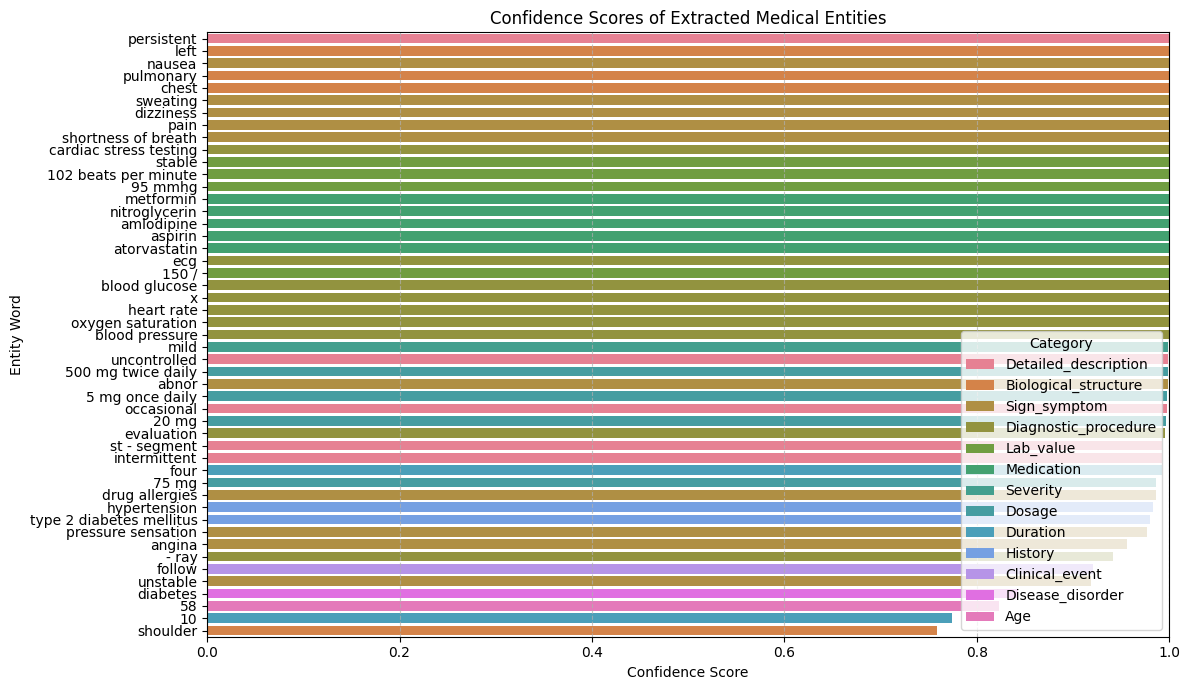


HEALTHCARE NLP ANALYSIS RESULT

INPUT REPORT
-----------------------------------------------------------------
1
Patient Name: Robert Wilson Age: 58 Gender: Male  Chief Complaints: The patient presented with persistent chest pain, shortness of breath, fatigue, and intermittent dizziness for the past four days. The pain was described as a mild pressure sensation radiating toward the left shoulder. The patient also reported occasional nausea and sweating during physical activity.  Medical History: The patient has a history of hypertension and type 2 diabetes mellitus for the past 10 years. He is currently 

[Text truncated]

EXTRACTED MEDICAL ENTITIES
-----------------------------------------------------------------

Age
  1. 58  |  Confidence: 0.823

Detailed_description
  1. persistent  |  Confidence: 1.0
  2. intermittent  |  Confidence: 0.993
  3. occasional  |  Confidence: 0.998
  4. st - segment  |  Confidence: 0.993
  5. uncontrolled  |  Confidence: 0.999

Biological_structure
  

In [ ]:
# MAIN PROGRAM

def main():

    ner_model, bart_model, bart_tokenizer = load_models()

    while True:

        text = get_user_input()

        print("\nProcessing report...\n")

        entities = extract_entities(
            text,
            ner_model
        )

        # Visualize the extracted entities
        visualize_entities(entities)

        summary = summarize_text(
            text,
            bart_model,
            bart_tokenizer
        )

        display_results(
            text,
            entities,
            summary
        )

        export_results(
            text,
            entities,
            summary
        )

        again = input(
            "\nProcess another report? (y/n): "
        ).strip().lower()

        if again != "y":

            print("\nProgram finished")
            break


main()